# Train model

In [1]:
import os
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import hayai_util

portfolio_id = 'model'

context = hayai_util.create_context(portfolio_id)

## Step 1: build the dataset

In [2]:
filename = os.path.join(context['portfolio_dir'], "features.parquet")
df = pd.read_parquet(filename)
# unisci le righe di tutti i dataframe in uno solo
df = df.dropna()
df.shape

(377170, 44)

## EDA

In [3]:
df.describe()

,AUDUSD,BZ,EURUSD,GBPUSD,GC,NZDUSD,USDCAD,USDCHF,USDJPY,^DJI,...,trend_50,vol_10,vol_20,vol_ratio,vol_regime,volume,volume_shock,volume_zscore,vwap,zscore_20
count,377170.000000,377170.000000,377170.000000,377170.000000,377170.000000,377170.000000,377170.000000,377170.000000,377170.000000,377170.000000,...,377170.000000,377170.000000,377170.000000,377170.000000,377170.000000,3.771700e+05,377170.000000,377170.000000,377170.000000,377170.000000
mean,0.656013,75.467836,1.105770,1.291931,2823.921499,0.596705,1.374915,0.858308,149.348206,40943.078779,...,0.018005,0.043541,0.051100,0.871736,0.936369,2.856783e+06,1.025781,0.030852,102.161058,0.095047
std,0.018335,8.338840,0.043312,0.041669,869.597380,0.018198,0.029077,0.043309,5.672589,4701.885020,...,0.160242,0.043451,0.045895,0.277298,0.376403,7.209613e+06,0.638646,1.047378,149.163663,1.310718
min,0.595529,58.919998,1.024443,1.207846,1816.599976,0.551849,1.311250,0.763200,133.464996,32417.589844,...,-0.922556,0.000682,0.001278,0.009301,0.006695,2.150000e+02,0.005890,-2.978068,0.045408,-4.248529
25%,0.644712,68.510002,1.076426,1.261766,2031.500000,0.584100,1.356300,0.811800,145.473007,37711.019531,...,-0.047482,0.020883,0.026590,0.669975,0.669608,5.154808e+05,0.692207,-0.643733,23.479233,-0.962599
50%,0.655400,75.169998,1.092037,1.279836,2617.199951,0.597150,1.370420,0.873450,149.201004,41198.078125,...,0.008043,0.033014,0.040221,0.889963,0.878783,1.155222e+06,0.891679,-0.241216,53.210150,0.143738
75%,0.666500,82.190002,1.151278,1.332392,3334.000000,0.610620,1.388980,0.895280,154.195007,44484.421875,...,0.069131,0.053108,0.062326,1.090115,1.137428,2.641072e+06,1.171828,0.424753,116.508322,1.151981
max,0.712530,96.550003,1.201764,1.382533,5318.399902,0.639190,1.471700,0.920970,161.606995,50188.140625,...,16.462674,1.942871,1.611193,1.448208,2.480680,3.902561e+08,20.000000,4.248529,2376.184086,4.248279


In [4]:
df = df.drop(columns=['date', 'symbol'])
df.info()

<class 'pandas.DataFrame'>
Index: 377170 entries, 481 to 620994
Data columns (total 42 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   AUDUSD                 377170 non-null  float64
 1   BZ                     377170 non-null  float64
 2   EURUSD                 377170 non-null  float64
 3   GBPUSD                 377170 non-null  float64
 4   GC                     377170 non-null  float64
 5   NZDUSD                 377170 non-null  float64
 6   USDCAD                 377170 non-null  float64
 7   USDCHF                 377170 non-null  float64
 8   USDJPY                 377170 non-null  float64
 9   ^DJI                   377170 non-null  float64
 10  ^GSPC                  377170 non-null  float64
 11  ^IXIC                  377170 non-null  float64
 12  ^RUT                   377170 non-null  float64
 13  ^VIX1D                 377170 non-null  float64
 14  close_range            377170 non-null  float64
 1

In [5]:
# raise an error if there are any missing values
if df.isnull().values.any():
    raise ValueError("There are missing values in the dataframe")

## Target analysis

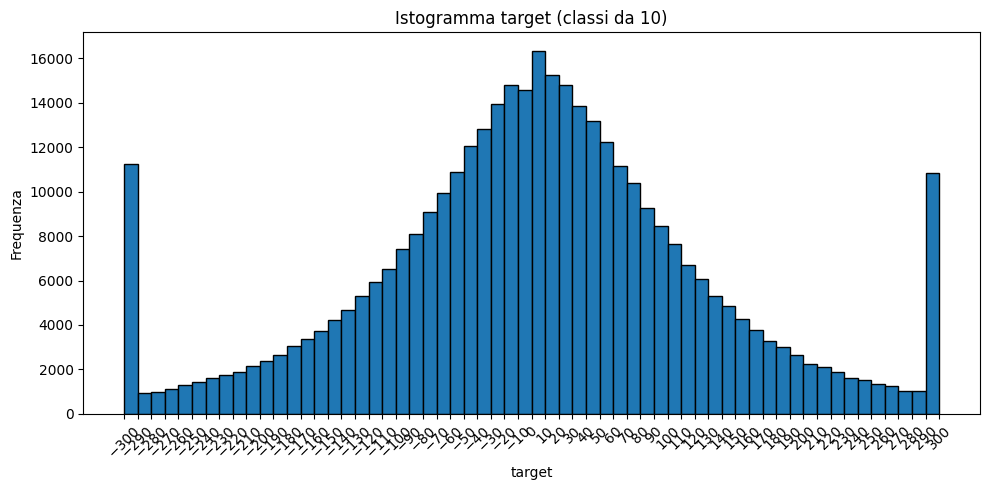

In [6]:
# Istogramma del target con classi (ampiezza) di 50
target_values = df['target']
target_values = target_values * 100
bin_start = math.floor(target_values.min() / 10) * 10
bin_end = math.ceil(target_values.max() / 10) * 10
bins = list(range(int(bin_start), int(bin_end) + 10, 10))

plt.figure(figsize=(10, 5))
plt.hist(target_values, bins=bins, edgecolor='black')
plt.title("Istogramma target (classi da 10)")
plt.xlabel("target")
plt.ylabel("Frequenza")
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

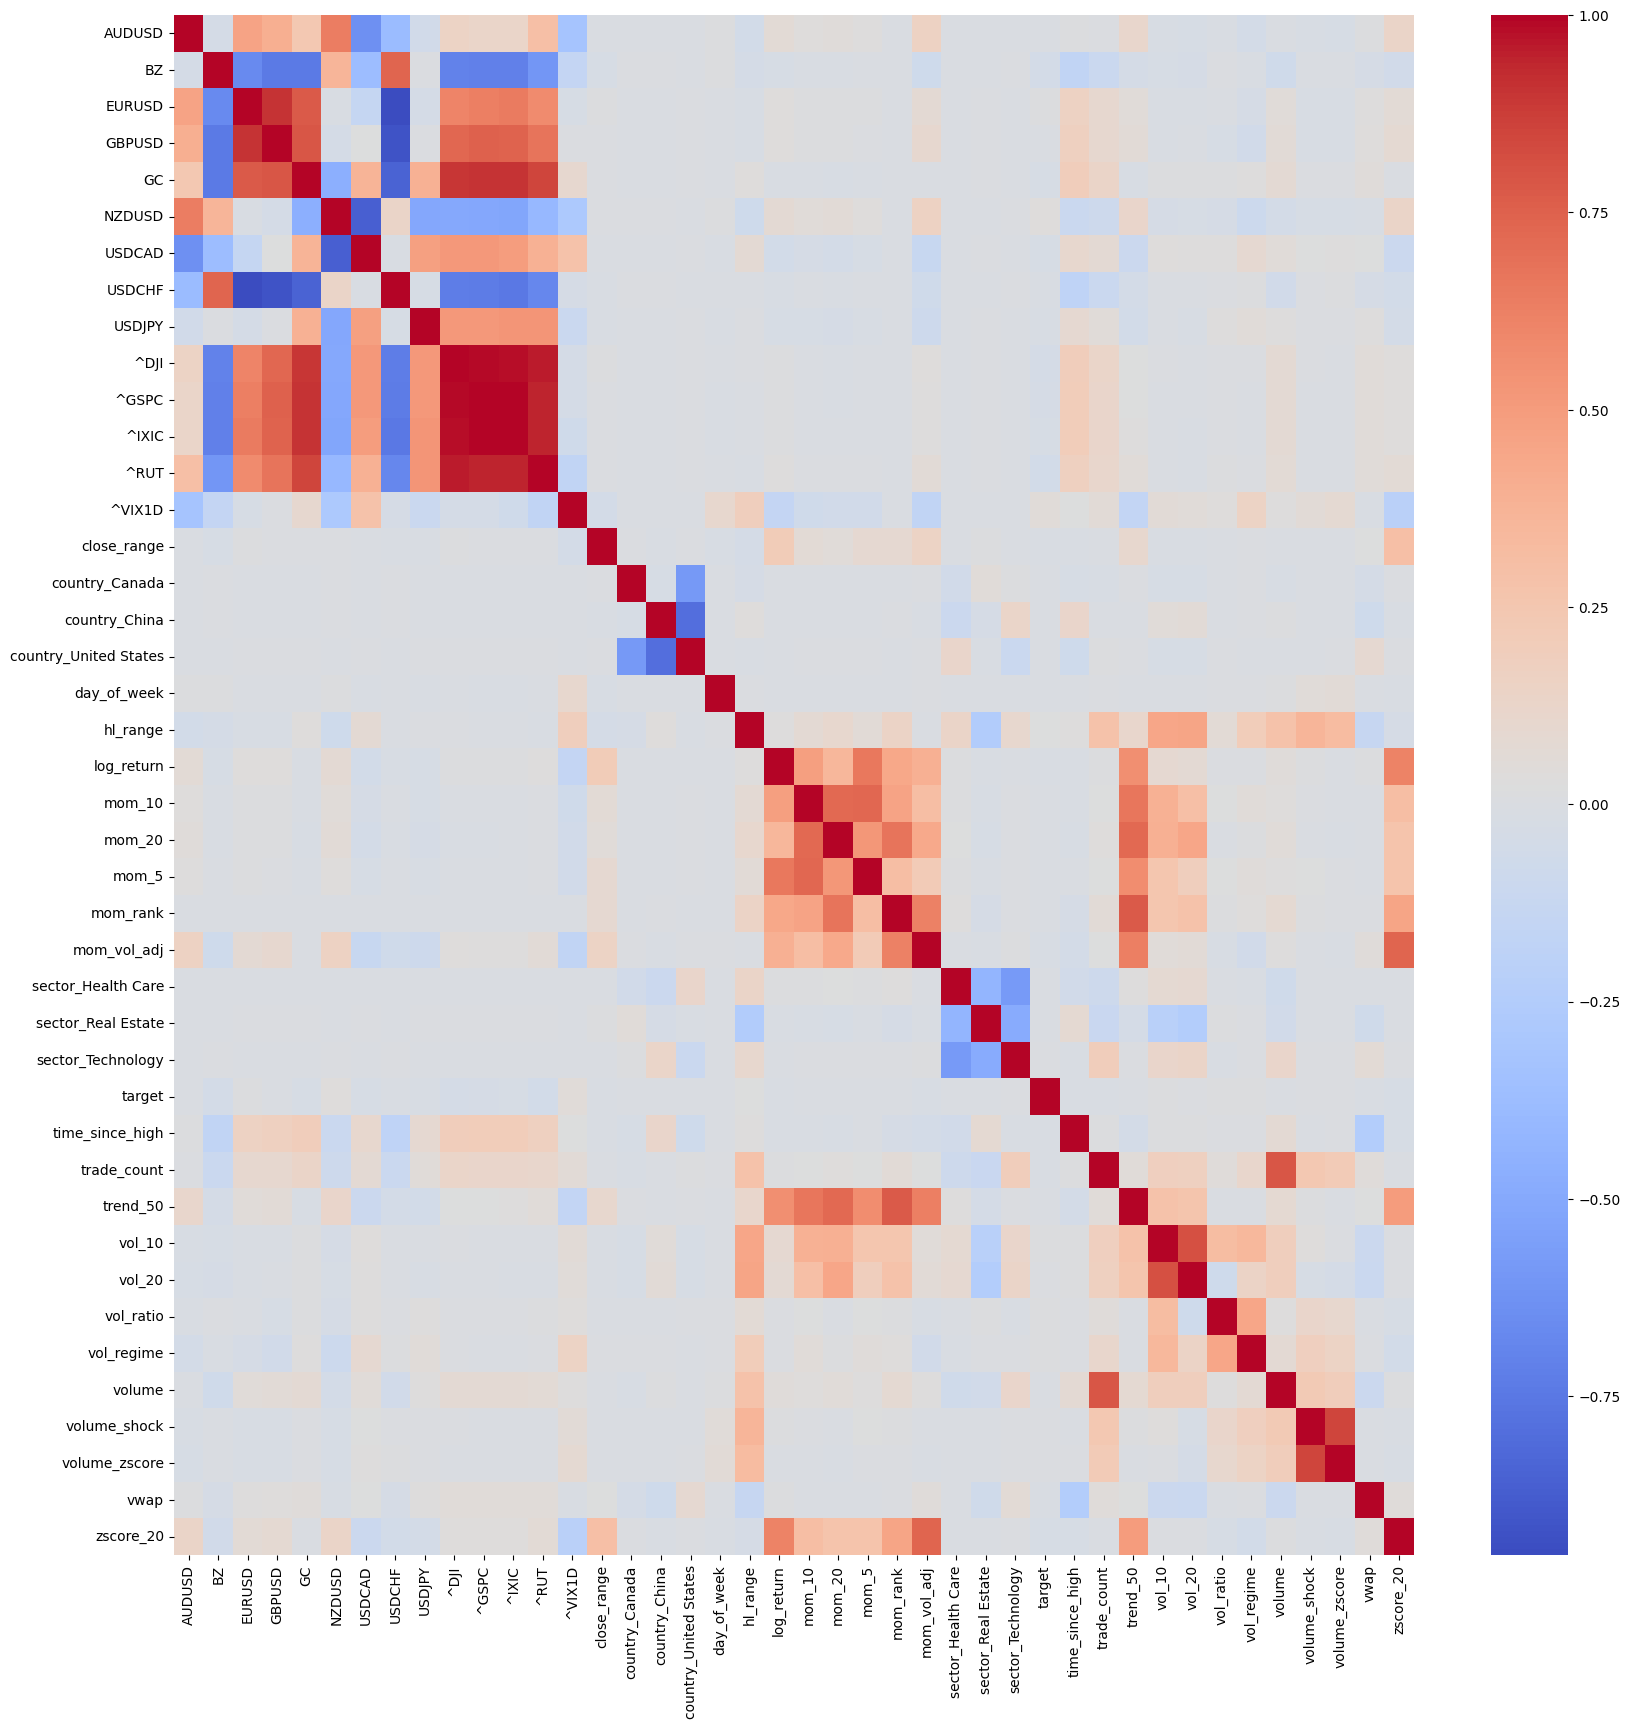

In [7]:
# display the correlation map using seaborn
plt.figure(figsize=(20, 20))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.show()

## Normalize

In [8]:
maxs = df.max()
mins = df.min()
df = (df - mins) / (maxs - mins)
label_min = mins['target']
label_max = maxs['target']
hayai_util.save_normalization_params(label_min, label_max)
maxs.index.name = "col"
maxs.name = "value"
maxs.to_csv(os.path.join(context['portfolio_dir'], "maxs.csv"), index=True)
mins.index.name = "col"
mins.name = "value"
mins.to_csv(os.path.join(context['portfolio_dir'], "mins.csv"), index=True)

## Model building

In [9]:
labels = df['target'].values
df = df.drop(columns=['target'])
data = df.values


In [10]:
from keras.models import Sequential
from keras.layers import Input, Dense,Conv1D,Conv2D,Flatten,MaxPool2D,BatchNormalization,MaxPooling1D
from keras.optimizers import Adam, SGD
from sklearn.model_selection import train_test_split
print("Labels Shape: %s" % (labels.shape,))
print("Data Shape: %s" % (data.shape,))
X, X_test, Y, Y_test = train_test_split(data, labels, test_size=0.2, random_state=1,shuffle=True)
print("Train Data Shape: %s" % (X.shape,))
print("Train Labels Shape: %s" % (Y.shape,))
print("Test Data Shape: %s" % (X_test.shape,))
print("Test Labels Shape: %s" % (Y_test.shape,))

Labels Shape: (377170,)
Data Shape: (377170, 41)
Train Data Shape: (301736, 41)
Train Labels Shape: (301736,)
Test Data Shape: (75434, 41)
Test Labels Shape: (75434,)


In [11]:
n_row = data.shape[1]
channels = 1 # non ci sono colori, il channel è 1 (usato solo in Conv2D)
batch_size = 64

model = Sequential()
model.add(Input(shape=(n_row,), name='input_layer'))
model.add(Dense(64, activation='relu',name='layerDense1'))
model.add(Dense(32, activation='relu',name='layerDense2'))
model.add(Dense(16, activation='relu',name='layerDense3'))
model.add(Dense(1,activation='sigmoid',name='output_layer'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layerDense1 (Dense)             │ (None, 64)             │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense2 (Dense)             │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layerDense3 (Dense)             │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,313 (20.75 KB)

 Trainable params: 5,313 (20.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# questa è la funzione di costo
optimizer = Adam(learning_rate=context['learning_rate'])
model.compile(loss='mean_squared_error', optimizer=optimizer)
#model.compile(loss='mean_squared_error', optimizer='SGD')

# questo è il training
model.fit(
    X,
    Y,
    epochs=context['epochs'],
    shuffle=True,
    verbose=2,
    batch_size=context['batch_size'],
    validation_split=context['validation_split']
)
# il modello è pronto, applichiamo il modello al dataset di test

results = model.evaluate(X_test, Y_test, verbose=2,)
print("Test loss: %f" % results)
filename = os.path.join(context['portfolio_dir'], 'model_summary.txt')
with open(filename, 'w',encoding='utf-8') as f:
    model.summary(print_fn=lambda x: f.write(x + '\n'))
model.save(os.path.join(context['portfolio_dir'], 'model.keras'))
print("Model saved to: %s" % os.path.join(context['portfolio_dir'], 'model.keras'))

Epoch 1/30
1886/1886 - 3s - 2ms/step - loss: 0.0424 - val_loss: 0.0417
Epoch 2/30
1886/1886 - 2s - 1ms/step - loss: 0.0409 - val_loss: 0.0410
Epoch 3/30
1886/1886 - 2s - 1ms/step - loss: 0.0402 - val_loss: 0.0407
Epoch 4/30
1886/1886 - 2s - 1ms/step - loss: 0.0396 - val_loss: 0.0397
Epoch 5/30
1886/1886 - 2s - 1ms/step - loss: 0.0391 - val_loss: 0.0393
Epoch 6/30
1886/1886 - 2s - 1ms/step - loss: 0.0387 - val_loss: 0.0390
Epoch 7/30
1886/1886 - 2s - 1ms/step - loss: 0.0384 - val_loss: 0.0390
Epoch 8/30
1886/1886 - 2s - 1ms/step - loss: 0.0381 - val_loss: 0.0390
Epoch 9/30
1886/1886 - 2s - 1ms/step - loss: 0.0379 - val_loss: 0.0386
Epoch 10/30
1886/1886 - 2s - 1ms/step - loss: 0.0377 - val_loss: 0.0380
Epoch 11/30
1886/1886 - 2s - 967us/step - loss: 0.0375 - val_loss: 0.0384
Epoch 12/30
1886/1886 - 2s - 963us/step - loss: 0.0374 - val_loss: 0.0379
Epoch 13/30
1886/1886 - 2s - 983us/step - loss: 0.0372 - val_loss: 0.0379
Epoch 14/30
1886/1886 - 2s - 987us/step - loss: 0.0371 - val_loss: 

Model saved to: data\model\model.keras


In [13]:
tp = 0
tn = 0
fp = 0
fn = 0
#denormalize labels
labels = Y_test * (label_max - label_min) + label_min
predictions = model.predict(X_test, verbose=0)
print("min and max of predictions ", predictions.min(), predictions.max())
errors = []
for i in range(len(X_test)):
    p = predictions[i][0]
    label = labels[i]
    p = p * (label_max - label_min) + label_min # denormalize prediction
    if i < 30:
        print(f"Label: {label:.4f}, Prediction: {p:.4f}")
    errors.append((label - p))
    if label > 0 and p > 0:
        tp += 1
    elif label <= 0 and p <= 0:
        tn += 1
    elif label <= 0 and p > 0:
        fp += 1
    elif label > 0 and p <= 0:
        fn += 1
eqm = math.sqrt(sum([e**2 for e in errors])/len(errors))
print(f"Mean Squared Error: {eqm:.4f}")
print("True Positives: %d, True Negatives: %d, False Positives: %d, False Negatives: %d" % (tp, tn, fp, fn))
print("positive labels: %d, negative labels: %d" % (sum(labels > 0), sum(labels <= 0)))
print("Sum true",tp+tn, "Sum false",fp+fn)
print("Precision: %.4f" % (tp / (tp + fp) if (tp + fp) > 0 else 0))
print("Recall: %.4f" % (tp / (tp + fn) if (tp + fn) > 0 else 0))
print("Accuracy: %.4f" % ((tp + tn) / len(X_test) if len(X_test) > 0 else 0))

pred_denorm = predictions.flatten() * (label_max - label_min) + label_min
corr = pd.Series(labels).corr(pd.Series(pred_denorm))
print(f"Correlation (labels vs predictions): {corr:.4f}")

min and max of predictions  0.094967194 0.88082
Label: 1.2396, Prediction: -0.0006
Label: -0.6660, Prediction: 0.1306
Label: -0.6641, Prediction: -0.1079
Label: 1.1936, Prediction: 1.2594
Label: 0.3706, Prediction: 0.6045
Label: 1.2334, Prediction: 0.6722
Label: -0.8734, Prediction: 0.8932
Label: 0.3837, Prediction: 0.3281
Label: -2.1136, Prediction: -0.1565
Label: -0.1123, Prediction: 0.1011
Label: -0.4594, Prediction: 0.1764
Label: -2.6569, Prediction: -0.1998
Label: 0.5045, Prediction: 0.8588
Label: 0.2488, Prediction: 0.5331
Label: -1.9908, Prediction: -0.0116
Label: -2.5885, Prediction: -0.1384
Label: 1.7253, Prediction: 0.2873
Label: 0.0000, Prediction: 0.4264
Label: -1.6466, Prediction: 0.5020
Label: -2.1526, Prediction: -0.3399
Label: -0.2074, Prediction: 0.4494
Label: 1.7197, Prediction: 1.1989
Label: 0.0479, Prediction: -0.3784
Label: -0.7533, Prediction: -0.3527
Label: -1.0458, Prediction: -0.1621
Label: 0.6590, Prediction: 0.2936
Label: 0.2043, Prediction: -0.0774
Label: 1.